In [1]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_classic.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.prompts import ChatPromptTemplate
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,List,Dict,Annotated,Optional
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from pydantic import BaseModel,Field
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader


In [2]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
load_dotenv(r'D:\Projects\AI_Powered_Recruitment_Agent\.env')
groq_api_key = os.environ['GROQ_API_KEY']

llm1 = ChatGroq(
    model='openai/gpt-oss-20b',#openai/gpt-oss-20b
    api_key=groq_api_key,
    temperature=0,
    max_tokens=300
)

llm2 = ChatGroq(
    model='llama-3.1-8b-instant',#openai/gpt-oss-20b
    api_key=groq_api_key,
    temperature=0,
    max_tokens=300
)
# llm = ChatOllama(
#     model = 'gemma:2b',
#     temperature=0
# )
# model = HuggingFaceEndpoint(
#     repo_id="mistralai/Mistral-7B-Instruct-v0.2",
#     task="text-generation"
# )

bot = HuggingFaceEndpoint(
    model="openai/gpt-oss-20b",
    task="conversational",
    temperature=0
)

llm3 = ChatHuggingFace(llm=bot)

In [3]:
class ResumeAnalysisState(TypedDict):
    resume_path: str
    jd_data: str

    skill_requirements: str
    
    resume_text: str
    ats_score: float
    overall_score: float
    weaknesses_and_suggestions: str
    

    skill_res_score: str

    improvements: str


In [4]:
def extract_data_from_resume(state: ResumeAnalysisState):
    file = state['resume_path']
    if hasattr(file, "name"):
        ext = file.name.split(".")[-1].lower()
    else:
        ext = file.split(".")[-1].lower()

    if ext == "pdf":
        loader = PyPDFLoader(file)
    elif ext == "docx":
        loader = Docx2txtLoader(file)
    elif ext == "txt":
        with open(file, "r", encoding="utf-8") as f:
            return f.read()
    else:
        return ""

    text = ""
    for doc in loader.load():
        text += doc.page_content

    return {
        'resume_text' : text
    }

In [5]:
skill_extraction_prompt_from_jd = ChatPromptTemplate.from_template("""
You are an expert recruitment assistant with deep knowledge of technical, soft, and domain-specific skills.

Your task is to **read the Job Description carefully** and extract all skills, tools, and requirements explicitly mentioned or clearly implied.

Categories to extract:
1. Technical Skills – programming languages, frameworks, databases, APIs, ML/AI concepts, algorithms.
2. Tools and Technologies – software tools, platforms, cloud services, DevOps tools, version control systems.
3. Soft Skills – communication, teamwork, leadership, problem-solving, critical thinking, adaptability, creativity.
4. Domain Knowledge – industry-specific knowledge such as AI, data science, finance, healthcare, engineering.
5. Other Requirements – certifications, degrees, methodologies, years of experience, specific achievements.

**Guidelines:**
- Extract only what is present or implied in the Job Description.
- Avoid adding skills not mentioned.
- Do not list duplicates.
- Use numbered lists for each category: 1., 2., 3., ...
- If a category has no skills, write "None".
- Be concise and precise; one skill per line.
- Do not include any explanation, comments, or extra text outside the format.

Return strictly in this format:

Technical Skills:
1. ...
2. ...

Tools and Technologies:
1. ...
2. ...

Soft Skills:
1. ...
2. ...

Domain Knowledge:
1. ...
2. ...

Other Requirements:
1. ...
2. ...

Job Description:
{jd_data}
""")
def extract_requirements_from_jd(
    state: ResumeAnalysisState
):
    jd = state['jd_data']

    parser = StrOutputParser()
    chain = skill_extraction_prompt_from_jd | llm2 | parser

    response = chain.invoke({
        'jd_data' : jd
    })
    return {
        'skill_requirements' : response
    }

    
    

In [6]:
class SkillAnalysisModel(BaseModel):
    skills_res_score: str = Field(
        description="Explain the reasoning for skill matching between the resume and job description in 3–4 points, then provide the final skill match score from 0 to 10."
    )
    
    overall_score: float = Field(
        description="Provide the overall suitability score for the candidate from 0 to 10 considering skills, experience relevance, and job alignment."
    )
    
    ats_score: float = Field(
        description="Estimate the ATS compatibility score from 0 to 100 based on keyword matching, skills, and job description relevance."
    )
ats_calc_prompt = ChatPromptTemplate.from_template("""
You are a STRICT ATS (Applicant Tracking System) evaluator.

Your job is to score how well the resume matches the job requirements.

Inputs:

Resume:
{resume_text}

Job Requirements:
{skill_requirements}

Evaluation Rules (VERY IMPORTANT):

1. Extract all required skills from the Job Requirements.
2. Compare them with the skills mentioned in the Resume.
3. Categorize them into:
   - Matched Skills
   - Partially Matched Skills
   - Missing Skills

Scoring Logic:

ATS Score (0–100):
- 90–100 → Almost all required skills present
- 70–89 → Many skills match but some missing
- 40–69 → Only partial skill match
- 10–39 → Very few skills match
- 0–9 → Almost no skills match or completely unrelated

STRICT RULES:
- If the resume domain is completely different from the job description → ATS score must be below 20.
- If less than 30% of required skills match → ATS score must be below 40.
- If there are zero technical skill matches → ATS score must be 0–10.
- Do NOT give high scores for unrelated resumes.

Overall Score (0–10):
Evaluate the overall suitability considering:
- Skill relevance
- Project relevance
- Domain alignment
- Experience level

Return the output strictly in JSON format:

{{
  "skills_res_score": "Explain reasoning in 3–4 short points including matched skills and missing skills, then give final skill match score out of 10.",
  "overall_score": number,
  "ats_score": number
}}

Important:
- ats_score must be a number between 0 and 100
- overall_score must be between 0 and 10
- Do NOT include any extra text outside JSON.
""")


def calculate_ats_score(state: ResumeAnalysisState):
    resume_text = state['resume_text']
    skill_requirements = state['skill_requirements']


    parser = PydanticOutputParser(pydantic_object=SkillAnalysisModel)


    chain = ats_calc_prompt | llm2 | parser

    response = chain.invoke(
        {
            'resume_text' : resume_text,
            'skill_requirements' : skill_requirements
        }
    )


    return {
        'skills_res_score' : response.skills_res_score,
        'overall_score' : response.overall_score,
        'ats_score' : response.ats_score
    }

In [7]:
suggestion_prompt = ChatPromptTemplate.from_template("""
You are an expert AI resume reviewer specializing in evaluating candidates for technical roles. Your task is to assess the resume against the job description and generate precise, actionable feedback.

Inputs:

Resume:
{resume_text}

Job Description:
{jd_data}

Instructions:
1. Identify all weaknesses, gaps, missing skills, unclear project relevance, or lack of experience compared to the job description.
2. For each identified weakness, provide a practical suggestion for improvement.
3. Structure your response strictly in two sections:
   Weaknesses: List each weakness as a separate point (full sentences or semicolons are allowed).
   Suggestions: Provide actionable suggestions corresponding to each weakness, in the same order.
4. Keep responses concise, professional, and directly relevant to the job.
5. Do NOT include any additional commentary, greetings, or text outside these two sections.
6. Example format:

Weaknesses: Candidate lacks Docker experience; limited cloud exposure; teamwork contributions unclear.
Suggestions: Learn Docker through online tutorials; participate in cloud-based projects; highlight teamwork and project outcomes clearly in the resume.
""")


def find_weakness_and_suggestion(state: ResumeAnalysisState):

    jd_data = state['jd_data']
    resume_text = state['resume_text']

    parser = StrOutputParser()

    chain = suggestion_prompt | llm2 | parser

    response = chain.invoke({
        'resume_text' : resume_text,
        'jd_data' : jd_data
    })
    return {
        'weaknesses_and_suggestions' : response
    }

In [8]:
improvement_prompt = ChatPromptTemplate.from_template(
    '''
You are an expert AI resume improvement advisor.

Your task is to analyze the candidate's resume and the job requirements, then provide specific improvements that would make the resume stronger for this role.

Inputs:

Resume:
{resume_text}

Job Requirements:
{jd_data}

Instructions:
- Suggest practical improvements that would increase the candidate's chances of getting shortlisted.
- Focus on improving project descriptions, adding relevant skills, highlighting experience, and improving ATS compatibility.
- Suggestions should be specific and actionable.

Guidelines:
- Write improvements in numbered points.
- Focus on skill development, project enhancement, and resume optimization.
- Ensure suggestions are directly related to the job description.

Return the result strictly according to the structured schema and do not include extra text outside the field.
'''
)
def improvements_needed(state: ResumeAnalysisState):
    jd_data = state['jd_data']
    resume_text = state['resume_text']

    parser = StrOutputParser()

    chain = improvement_prompt | llm1 | parser

    response = chain.invoke(
        {
            'resume_text' : resume_text,
            'jd_data' : jd_data
        }
    )
    return {
        'improvements' : response
    }

In [9]:
def merge_extraction_state(state):
    """
    This node does nothing but ensures the state from 
    both extraction nodes is merged before downstream nodes run.
    """
    return state

In [10]:
graph = StateGraph(ResumeAnalysisState)



graph.add_node('extract_data_from_resume',extract_data_from_resume)
graph.add_node('extract_requirements_from_jd',extract_requirements_from_jd)
graph.add_node('calculate_ats_score',calculate_ats_score)
graph.add_node('find_weakness_and_suggestion',find_weakness_and_suggestion)
graph.add_node('improvements_needed',improvements_needed)
graph.add_node('merge_extraction_state',merge_extraction_state)

graph.add_edge(START,'extract_data_from_resume')
graph.add_edge(START,'extract_requirements_from_jd')


graph.add_edge('extract_data_from_resume','merge_extraction_state')
graph.add_edge('extract_requirements_from_jd','merge_extraction_state')

graph.add_edge('merge_extraction_state','calculate_ats_score')
graph.add_edge('merge_extraction_state','improvements_needed')
graph.add_edge('merge_extraction_state','find_weakness_and_suggestion')

graph.add_edge('calculate_ats_score',END)
graph.add_edge('improvements_needed',END)
graph.add_edge('find_weakness_and_suggestion',END)

agent = graph.compile()

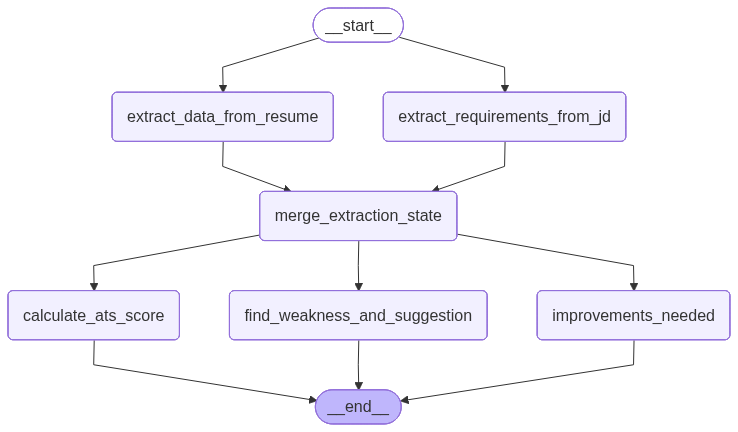

In [11]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [12]:
jd = """
We are seeking a highly motivated AI/ML Engineer to join our data science team. 
The ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.

Required Skills:
- Programming Languages: Python, R, Java
- Machine Learning: Scikit-learn, XGBoost, LightGBM
- Deep Learning: TensorFlow, PyTorch, Keras
- Data Handling: NumPy, Pandas, SQL
- Data Visualization: Matplotlib, Seaborn, Plotly
- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git
- APIs & Deployment: REST APIs, Flask, FastAPI
- Soft Skills: Problem-solving, analytical thinking, teamwork

Preferred Experience:
- Developing and deploying ML/DL models
- Natural Language Processing (NLP) or Computer Vision projects
- Data preprocessing, feature engineering, and model optimization
- Writing clean, modular, and testable code
"""


In [13]:
initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)


In [14]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': '\nWe are seeking a highly motivated AI/ML Engineer to join our data science team. \nThe ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.\n\nRequired Skills:\n- Programming Languages: Python, R, Java\n- Machine Learning: Scikit-learn, XGBoost, LightGBM\n- Deep Learning: TensorFlow, PyTorch, Keras\n- Data Handling: NumPy, Pandas, SQL\n- Data Visualization: Matplotlib, Seaborn, Plotly\n- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git\n- APIs & Deployment: REST APIs, Flask, FastAPI\n- Soft Skills: Problem-solving, analytical thinking, teamwork\n\nPreferred Experience:\n- Developing and deploying ML/DL models\n- Natural Language Processing (NLP) or Computer Vision projects\n- Data preprocessing, feature engineering, and model optimization\n- Writing clean, modular, and testable code\n',
 'skill_requirements': 'Technical Skills:\n1

In [15]:
response['skill_requirements']

'Technical Skills:\n1. Python\n2. R\n3. Java\n4. Scikit-learn\n5. XGBoost\n6. LightGBM\n7. TensorFlow\n8. PyTorch\n9. Keras\n10. NumPy\n11. Pandas\n12. SQL\n13. Matplotlib\n14. Seaborn\n15. Plotly\n16. REST APIs\n17. Flask\n18. FastAPI\n\nTools and Technologies:\n1. AWS\n2. Google Cloud Platform\n3. Docker\n4. Git\n\nSoft Skills:\n1. Problem-solving\n2. Analytical thinking\n3. Teamwork\n\nDomain Knowledge:\n1. AI\n2. Machine Learning\n3. Data Science\n4. Data Analytics\n5. Deep Learning\n\nOther Requirements:\n1. Experience in developing and deploying ML/DL models\n2. Experience in NLP or Computer Vision projects\n3. Experience in data preprocessing, feature engineering, and model optimization\n4. Ability to write clean, modular, and testable code'

In [16]:
jd ='''
Position: Web Developer
Experience: 0–2 years
Responsibilities:
- Develop web applications using HTML, CSS, and JavaScript.
- Build back-end APIs using Python (Django/Flask) or Node.js.
- Collaborate with designers to implement UI/UX.
- Optimize applications for speed and scalability.
- Maintain and update existing websites.
Required Skills:
- Proficient in HTML, CSS, JavaScript.
- Knowledge of Python or Node.js.

- Understanding of REST APIs and version control (Git).
Preferred Skills:
- Experience with React, Angular, or Vue.js.
- Knowledge of cloud deployment (AWS, Azure).'''

In [17]:
initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)


In [18]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': '\nPosition: Web Developer\nExperience: 0–2 years\nResponsibilities:\n- Develop web applications using HTML, CSS, and JavaScript.\n- Build back-end APIs using Python (Django/Flask) or Node.js.\n- Collaborate with designers to implement UI/UX.\n- Optimize applications for speed and scalability.\n- Maintain and update existing websites.\nRequired Skills:\n- Proficient in HTML, CSS, JavaScript.\n- Knowledge of Python or Node.js.\n\n- Understanding of REST APIs and version control (Git).\nPreferred Skills:\n- Experience with React, Angular, or Vue.js.\n- Knowledge of cloud deployment (AWS, Azure).',
 'skill_requirements': 'Technical Skills:\n1. HTML\n2. CSS\n3. JavaScript\n4. Python\n5. Node.js\n6. Django\n7. Flask\n8. REST APIs\n\nTools and Technologies:\n1. Git\n2. React\n3. Angular\n4. Vue.js\n5. AWS\n6. Azure\n\nSoft Skills:\n1. Collaboration\n2. Problem-solving\n3. Adaptability\n\nDomain Knowledge:\n1. Web Development\n\nOther Requirement

In [19]:
jd = '''
Position: Physics Research Assistant
Experience: 0–2 years

Responsibilities:

Assist in conducting physics experiments and collecting experimental data.

Analyze physical systems and interpret results using scientific methods.

Support researchers in designing experiments and simulations.

Document experimental procedures and research findings.

Collaborate with research teams to solve complex physical problems.

Required Skills:

Strong understanding of fundamental physics concepts.

Analytical thinking and problem-solving ability.

Ability to interpret scientific data and experimental results.

Good documentation and research skills.

Preferred Skills:

Experience working in laboratory environments.
'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)


In [20]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': '\nPosition: Physics Research Assistant\nExperience: 0–2 years\n\nResponsibilities:\n\nAssist in conducting physics experiments and collecting experimental data.\n\nAnalyze physical systems and interpret results using scientific methods.\n\nSupport researchers in designing experiments and simulations.\n\nDocument experimental procedures and research findings.\n\nCollaborate with research teams to solve complex physical problems.\n\nRequired Skills:\n\nStrong understanding of fundamental physics concepts.\n\nAnalytical thinking and problem-solving ability.\n\nAbility to interpret scientific data and experimental results.\n\nGood documentation and research skills.\n\nPreferred Skills:\n\nExperience working in laboratory environments.\n',
 'skill_requirements': 'Technical Skills:\n1. Analytical thinking\n2. Problem-solving ability\n\nTools and Technologies:\nNone\n\nSoft Skills:\n1. Documentation skills\n2. Research skills\n3. Collaboration s

In [21]:
jd = '''
Position: Data Scientist
Experience: 0–2 years

Responsibilities:

Build and train machine learning models for predictive analytics.

Perform data preprocessing, feature engineering, and model evaluation.

Conduct exploratory data analysis (EDA) to extract insights from datasets.

Develop and evaluate deep learning models for complex prediction tasks.

Collaborate with teams to deploy data-driven solutions.

Required Skills:

Machine learning and supervised learning techniques.

Experience with neural networks and deep learning frameworks.

Data preprocessing and exploratory data analysis.

Model evaluation and performance optimization.

Preferred Skills:

Experience working with NLP systems.

Knowledge of generative AI systems.

Experience working with large datasets.
'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [22]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': '\nPosition: Data Scientist\nExperience: 0–2 years\n\nResponsibilities:\n\nBuild and train machine learning models for predictive analytics.\n\nPerform data preprocessing, feature engineering, and model evaluation.\n\nConduct exploratory data analysis (EDA) to extract insights from datasets.\n\nDevelop and evaluate deep learning models for complex prediction tasks.\n\nCollaborate with teams to deploy data-driven solutions.\n\nRequired Skills:\n\nMachine learning and supervised learning techniques.\n\nExperience with neural networks and deep learning frameworks.\n\nData preprocessing and exploratory data analysis.\n\nModel evaluation and performance optimization.\n\nPreferred Skills:\n\nExperience working with NLP systems.\n\nKnowledge of generative AI systems.\n\nExperience working with large datasets.\n',
 'skill_requirements': 'Technical Skills:\n1. Machine learning\n2. Supervised learning techniques\n3. Neural networks\n4. Deep learning

In [25]:
jd = '''Job Title: AI / Machine Learning Engineer (Entry Level)

Experience: 0–2 years

Job Description:
We are looking for a motivated AI / Machine Learning Engineer to assist in developing intelligent systems and data-driven applications. The candidate will work on building machine learning models, analyzing data, and integrating AI solutions into software applications.

Responsibilities:

Develop and train machine learning models for prediction and classification tasks.

Perform data preprocessing, exploratory data analysis (EDA), and feature engineering.

Build NLP pipelines for text processing and language-based applications.

Evaluate model performance and improve model accuracy.

Work with large datasets and perform data analysis and visualization.

Collaborate with engineering teams to integrate AI models into applications.

Required Skills:

Strong programming knowledge in Python.

Knowledge of machine learning concepts such as supervised learning, neural networks, and model evaluation.

Experience with machine learning libraries such as PyTorch and Scikit-learn.

Experience with data analysis tools like Pandas, Matplotlib, and Seaborn.

Knowledge of data preprocessing and exploratory data analysis techniques.

Understanding of NLP libraries such as NLTK.

Familiarity with databases such as MySQL, SQLite, or PostgreSQL.

Preferred Skills:

Experience working with LLM frameworks such as LangChain or LangGraph.

Knowledge of generative AI systems and AI pipelines.

Familiarity with Git-based version control and collaborative development.

Experience working with Jupyter Notebook or similar development tools.'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [26]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': 'Job Title: AI / Machine Learning Engineer (Entry Level)\n\nExperience: 0–2 years\n\nJob Description:\nWe are looking for a motivated AI / Machine Learning Engineer to assist in developing intelligent systems and data-driven applications. The candidate will work on building machine learning models, analyzing data, and integrating AI solutions into software applications.\n\nResponsibilities:\n\nDevelop and train machine learning models for prediction and classification tasks.\n\nPerform data preprocessing, exploratory data analysis (EDA), and feature engineering.\n\nBuild NLP pipelines for text processing and language-based applications.\n\nEvaluate model performance and improve model accuracy.\n\nWork with large datasets and perform data analysis and visualization.\n\nCollaborate with engineering teams to integrate AI models into applications.\n\nRequired Skills:\n\nStrong programming knowledge in Python.\n\nKnowledge of machine learning c

In [28]:
jd = '''Job Title: AI / Machine Learning Engineer (Entry Level)

Location: India
Experience: 0–2 Years

Job Description

We are seeking a passionate AI / Machine Learning Engineer to design and develop intelligent systems that leverage machine learning, natural language processing, and data-driven decision-making. The candidate will work on building scalable AI solutions, developing machine learning models, and implementing data pipelines for real-world applications.

Responsibilities

Develop machine learning and deep learning models for prediction, classification, and recommendation systems.

Perform data preprocessing, feature engineering, and exploratory data analysis (EDA).

Build and evaluate models using modern machine learning frameworks.

Develop NLP pipelines for text processing and conversational AI systems.

Design AI workflows and reasoning pipelines for intelligent applications.

Work with structured and unstructured datasets for model training and evaluation.

Visualize and interpret data to extract meaningful insights.

Maintain databases for storing and retrieving application data.

Collaborate with development teams to integrate AI models into software systems.

Conduct experiments to improve model performance and scalability.

Required Skills

Strong programming skills in Python.

Understanding of machine learning algorithms and neural networks.

Experience with PyTorch or similar deep learning frameworks.

Knowledge of data preprocessing, model evaluation, and supervised learning.

Experience with data analysis libraries such as Pandas, Matplotlib, and Seaborn.

Understanding of natural language processing concepts and text processing.

Knowledge of databases such as MySQL, SQLite, or PostgreSQL.

Familiarity with version control systems and collaborative development workflows.

Preferred Skills

Experience building LLM-based applications or conversational AI systems.

Knowledge of AI workflow orchestration or agent-based systems.

Experience working with memory-augmented AI architectures.

Familiarity with data-driven decision support systems.

Experience designing scalable AI systems and modular architectures.

Education

Bachelor's degree in Computer Science, Artificial Intelligence, Data Science, or a related field.

Ideal Candidate

Strong interest in Artificial Intelligence, Machine Learning, NLP, and Generative AI.

Experience working on AI projects involving real-world datasets.

Ability to design scalable and modular AI systems.

Strong analytical thinking and problem-solving skills'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [29]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': "Job Title: AI / Machine Learning Engineer (Entry Level)\n\nLocation: India\nExperience: 0–2 Years\n\nJob Description\n\nWe are seeking a passionate AI / Machine Learning Engineer to design and develop intelligent systems that leverage machine learning, natural language processing, and data-driven decision-making. The candidate will work on building scalable AI solutions, developing machine learning models, and implementing data pipelines for real-world applications.\n\nResponsibilities\n\nDevelop machine learning and deep learning models for prediction, classification, and recommendation systems.\n\nPerform data preprocessing, feature engineering, and exploratory data analysis (EDA).\n\nBuild and evaluate models using modern machine learning frameworks.\n\nDevelop NLP pipelines for text processing and conversational AI systems.\n\nDesign AI workflows and reasoning pipelines for intelligent applications.\n\nWork with structured and unstruc